In [4]:
import duckdb
import matplotlib.pyplot as plt
con = duckdb.connect("../data/basket.duckdb", read_only=True)
plt.rcParams["figure.figsize"] = (8, 4)

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: n_orders, dtype: float64


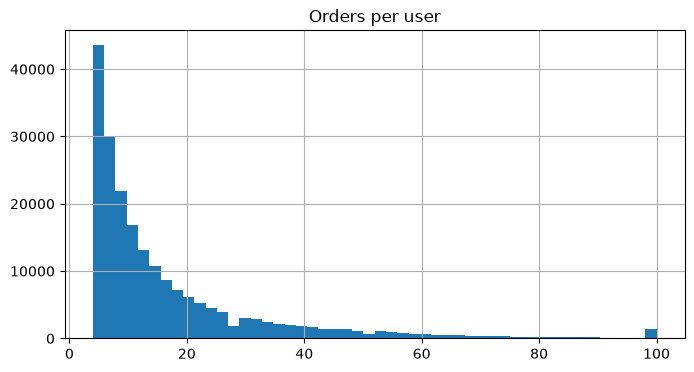

In [19]:
## Q1: How many orders does each user have?

q1 = con.execute("""
    SELECT user_id, count(*) as n_orders
    FROM orders
    GROUP BY user_id
""").df()

print(q1.n_orders.describe())
q1.n_orders.hist(bins=50)
plt.title("Orders per user")
plt.show()



In [11]:
import pandas as pd

# Display numbers nicely formatted up to 2 decimal places with commas
pd.set_option("display.float_format", lambda x: "%.2f" % x)


count   3214874.00
mean         10.09
std           7.53
min           1.00
25%           5.00
50%           8.00
75%          14.00
max         145.00
Name: basket_size, dtype: float64


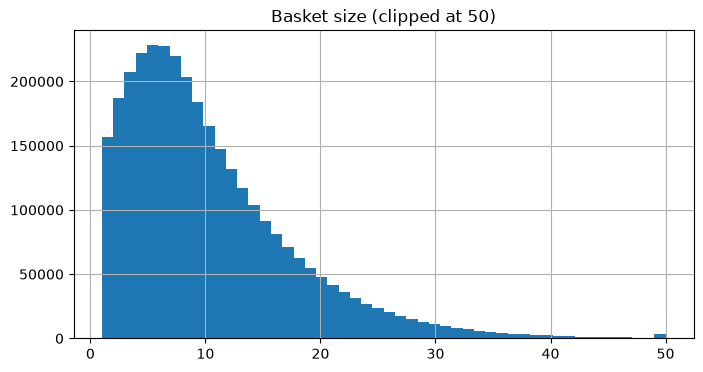

In [12]:
## Q2: How big is a basket?

q2 = con.execute("""
    SELECT order_id, COUNT(*) AS basket_size
    FROM order_products__prior
    GROUP BY order_id
""").df()

print(q2.basket_size.describe())
q2.basket_size.clip(upper=50).hist(bins=50)
plt.title("Basket size (clipped at 50)")
plt.show()



<Axes: title={'center': 'Reorder rate by department'}, ylabel='department'>

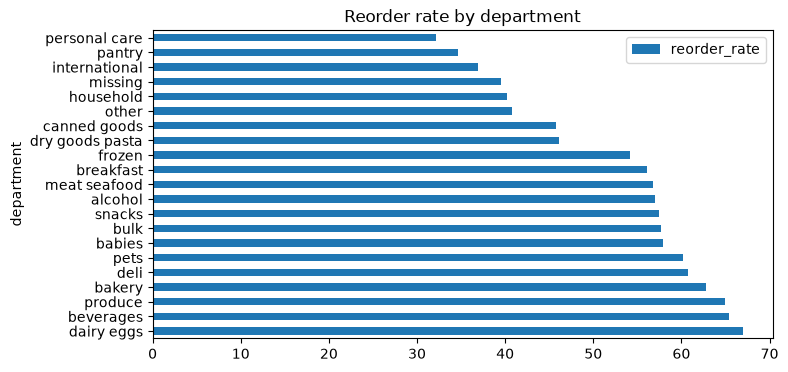

In [28]:
## Q3: Reorder rate by department

q3 = con.execute("""
    SELECT d.department,
    AVG(op.reordered)*100 AS reorder_rate
    From order_products__prior op
    JOIN products p using (product_id)
    JOIN departments d using (department_id)
    GROUP BY d.department
    order by reorder_rate desc
""").df()

q3.plot.barh(x="department", y="reorder_rate", legend=True, title="Reorder rate by department")

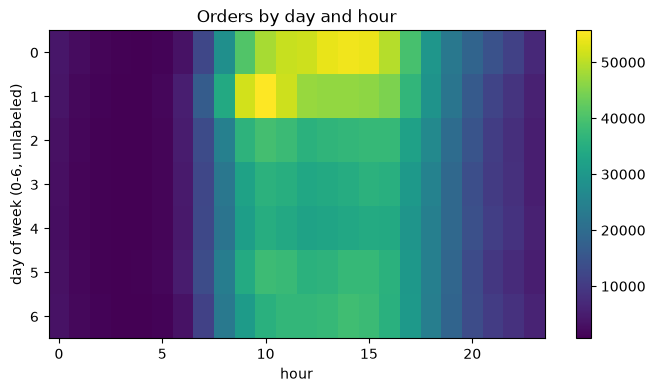

In [39]:
## Q4: When do people order?

q4 = con.execute("""
    SELECT order_dow, order_hour_of_day, COUNT(*) AS n_orders
    FROM orders
    GROUP BY order_dow, order_hour_of_day""").df()

pivot = q4.pivot(index="order_dow", columns="order_hour_of_day", values="n_orders")
plt.imshow(pivot, aspect="auto")
plt.colorbar()
plt.xlabel("hour")
plt.ylabel("day of week (0-6, unlabeled)")
plt.title("Orders by day and hour")
plt.show()

Top 20 Products:
                product_name       n
0                     Banana  472565
1     Bag of Organic Bananas  379450
2       Organic Strawberries  264683
3       Organic Baby Spinach  241921
4       Organic Hass Avocado  213584
5            Organic Avocado  176815
6                Large Lemon  152657
7               Strawberries  142951
8                      Limes  140627
9         Organic Whole Milk  137905
10       Organic Raspberries  137057
11      Organic Yellow Onion  113426
12            Organic Garlic  109778
13          Organic Zucchini  104823
14       Organic Blueberries  100060
15            Cucumber Kirby   97315
16        Organic Fuji Apple   89632
17             Organic Lemon   87746
18  Apple Honeycrisp Organic   85020
19    Organic Grape Tomatoes   84255

Products covering 50% of purchases: 787
Products covering 80% of purchases: 4,538


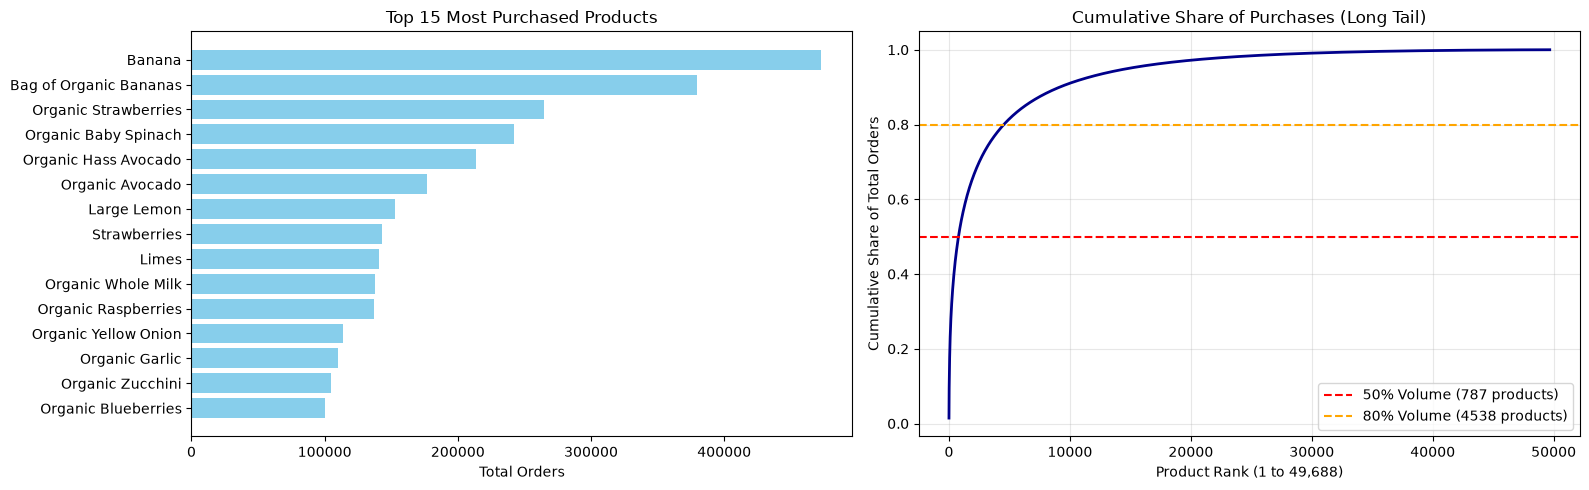

In [43]:
## Q5: Top products and the long tail

import matplotlib.pyplot as plt

# 1. SQL Query to get order counts per product
q5 = con.execute("""
    SELECT p.product_name, COUNT(*) AS n
    FROM order_products__prior op
    JOIN products p USING (product_id)
    GROUP BY 1
    ORDER BY n DESC
""").df()

# 2. Calculate cumulative share
q5["cum_share"] = q5.n.cumsum() / q5.n.sum()

# Milestone calculations
prod_50 = (q5.cum_share < 0.5).sum() + 1
prod_80 = (q5.cum_share < 0.8).sum() + 1

print(f"Top 20 Products:\n{q5[['product_name', 'n']].head(20)}\n")
print(f"Products covering 50% of purchases: {prod_50:,}")
print(f"Products covering 80% of purchases: {prod_80:,}")

# 3. Enhanced Visualization (2 Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot A: Top 15 Most Purchased Products
top_15 = q5.head(15).sort_values("n", ascending=True)
ax1.barh(top_15["product_name"], top_15["n"], color="skyblue")
ax1.set_title("Top 15 Most Purchased Products")
ax1.set_xlabel("Total Orders")

# Plot B: Cumulative Share Curve (The Long Tail)
ax2.plot(q5.cum_share.values, color="darkblue", linewidth=2)
ax2.axhline(0.5, color="red", linestyle="--", label=f"50% Volume ({prod_50} products)")
ax2.axhline(0.8, color="orange", linestyle="--", label=f"80% Volume ({prod_80} products)")

# Format plot B
ax2.set_title("Cumulative Share of Purchases (Long Tail)")
ax2.set_xlabel("Product Rank (1 to 49,688)")
ax2.set_ylabel("Cumulative Share of Total Orders")
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()